# 05d — TerSeg (Dual-Branch ResNet-34 + Swin-Tiny)

**Paper**: Fan et al. — *TerSeg: A dual-branch semantic segmentation network for Mars terrain and autonomous path planning*  
DOI: `10.1016/j.eswa.2025.126397` — Expert Systems With Applications 270 (2025)  

**Arquitectura**:  
- **Branch_C**: ResNet-34 pretrained — extrae features locales  
- **Branch_T**: Swin-Tiny (timm, pretrained) — extrae features globales  
- **FL/FG modules**: fusión ponderada entre ramas (local-first en capas tempranas, global-first en capas tardías)  
- **FLGA decoder**: agrega features multi-escala de distintas granularidades  

**Limitación importante**: Swin-Tiny pretrained requiere input 224×224.  
Solución: interpolación de los feature maps de entrada antes de Branch_T, no de la imagen completa.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/ai4mars_DL-v3')
    sys.path.append(str(PROJECT_ROOT / 'notebooks'))
else:
    # En local: este notebook está en notebooks/, root es el padre
    PROJECT_ROOT = Path.cwd().parent
    if not (PROJECT_ROOT / 'processed').exists():
        PROJECT_ROOT = Path.cwd().parent.parent

print(f'ROOT: {PROJECT_ROOT} | existe: {PROJECT_ROOT.exists()}')

ROOT: c:\Users\Hp\Documents\GitHub\ai4mars_DL-v3 | existe: True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet34, ResNet34_Weights
import timm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from mars_utils import (
    set_seed, load_norm_stats, load_split,
    build_dataloaders, FocalLoss,
    train_one_epoch, evaluate, train_model, run_multi_seed,
    append_benchmark_results, plot_best_seed_curves,
    print_summary_table, visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX, SEEDS, BENCHMARK_CSV, CHECKPOINTS_DIR
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Configuración

In [3]:
MODEL_NAME   = 'TerSeg'
FAST_SUBSET  = False  # False = entrenamiento completo; True solo para debug local

LR           = 1e-4
MAX_EPOCHS   = 80
PATIENCE     = 10
BATCH_SIZE   = 32
NUM_WORKERS  = 6
FOCAL_ALPHA  = 0.25
FOCAL_GAMMA  = 2.0

# Dimensiones del Swin-Tiny pretrained
SWIN_IMG_SIZE = 224   # limitación del pretrained; las imágenes se interpolan internamente

print(f'Modo: {"FAST SUBSET" if FAST_SUBSET else "PRODUCCIÓN"}')
print(f'Batch size: {BATCH_SIZE} | num_workers: {NUM_WORKERS}')
print(f'SWIN input interpolado a: {SWIN_IMG_SIZE}×{SWIN_IMG_SIZE}')


Modo: PRODUCCIÓN
Batch size: 32 | num_workers: 6
SWIN input interpolado a: 224×224


## 2. Datos

In [18]:
df_train, df_val, df_gold = load_split()
mean, std = load_norm_stats()

# ── Bug 6 fix: derivar stem de image_path, NO usar df_train['stem'] ──
train_ids = set(Path(p).stem for p in df_train['image_path'])
gold_ids  = set(Path(p).stem for p in df_gold['image_path'])
assert len(train_ids & gold_ids) == 0, '⚠️ DATA LEAKAGE detectado'
print(f'✅ Train: {len(df_train)} | Val: {len(df_val)} | Gold: {len(df_gold)}')
print(f'Normalización — mean: {mean} | std: {std}')

✅ Split cargado — train: 4200 | val: 1800 | gold test: 322
✅ Train: 4200 | Val: 1800 | Gold: 322
Normalización — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021] | std: [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]


## 3. Arquitectura — TerSeg

In [19]:
class FusionModule(nn.Module):
    """Fusión ligera FL/FG: proyecta ambas ramas a un ancho común."""
    def __init__(self, cnn_ch: int, tr_ch: int, out_ch: int, cnn_dominant: bool = True):
        super().__init__()
        self.cnn_proj = nn.Conv2d(cnn_ch, out_ch, 1, bias=False)
        self.tr_proj  = nn.Conv2d(tr_ch,  out_ch, 1, bias=False)

        init_cnn = 0.7 if cnn_dominant else 0.3
        self.w_cnn = nn.Parameter(torch.tensor(init_cnn))
        self.w_tr  = nn.Parameter(torch.tensor(1.0 - init_cnn))
        self.norm   = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU(inplace=True)

    def forward(self, r, t):
        if r.shape[-2:] != t.shape[-2:]:
            t = F.interpolate(t, size=r.shape[-2:], mode='bilinear', align_corners=False)
        fused = self.w_cnn * self.cnn_proj(r) + self.w_tr * self.tr_proj(t)
        return self.relu(self.norm(fused))


In [20]:
class FLGA(nn.Module):
    """Decoder progresivo ligero usado por la implementación rápida de TerSeg v2."""
    def __init__(self, channels: list[int], num_classes: int):
        super().__init__()
        self.ups = nn.ModuleList()
        self.convs = nn.ModuleList()

        for i in range(len(channels) - 1, 0, -1):
            self.ups.append(nn.Sequential(
                nn.Conv2d(channels[i], channels[i - 1], 1, bias=False),
                nn.BatchNorm2d(channels[i - 1]),
                nn.ReLU(inplace=True),
            ))
            self.convs.append(nn.Sequential(
                nn.Conv2d(channels[i - 1] * 2, channels[i - 1], 3, padding=1, bias=False),
                nn.BatchNorm2d(channels[i - 1]),
                nn.ReLU(inplace=True),
            ))

        self.head = nn.Conv2d(channels[0], num_classes, 1)

    def forward(self, features: list[torch.Tensor]):
        x = features[-1]
        skips = features[:-1][::-1]

        for up, conv, skip in zip(self.ups, self.convs, skips):
            x = up(x)
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = conv(torch.cat([x, skip], dim=1))

        return self.head(x)


In [21]:
class TerSeg(nn.Module):
    """TerSeg ligero: ResNet-34 + Swin-Tiny con fusiones a 64 canales."""
    def __init__(self, num_classes: int = NUM_CLASSES, out_ch: int = 64,
                 swin_img_size: int = 224):
        super().__init__()
        self.swin_img_size = swin_img_size

        # Branch_C: ResNet-34
        rn = resnet34(weights=ResNet34_Weights.DEFAULT)
        self.c_stem   = nn.Sequential(rn.conv1, rn.bn1, rn.relu, rn.maxpool)
        self.c_layer1 = rn.layer1   # 64ch,  H/4
        self.c_layer2 = rn.layer2   # 128ch, H/8
        self.c_layer3 = rn.layer3   # 256ch, H/16
        self.c_layer4 = rn.layer4   # 512ch, H/32

        # Branch_T: Swin-Tiny
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        swin_chs = self.swin.feature_info.channels()  # [96, 192, 384, 768]

        # FL: etapas locales dominadas por CNN; FG: etapas globales dominadas por Swin.
        self.fl1 = FusionModule(64,  swin_chs[0], out_ch, cnn_dominant=True)
        self.fl2 = FusionModule(128, swin_chs[1], out_ch, cnn_dominant=True)
        self.fg3 = FusionModule(256, swin_chs[2], out_ch, cnn_dominant=False)
        self.fg4 = FusionModule(512, swin_chs[3], out_ch, cnn_dominant=False)

        self.decoder = FLGA([out_ch] * 4, num_classes)

    def _swin_forward(self, x):
        x_swin = F.interpolate(
            x,
            size=(self.swin_img_size, self.swin_img_size),
            mode='bilinear',
            align_corners=False,
        )
        feats = self.swin(x_swin)
        return [f.permute(0, 3, 1, 2).contiguous() if f.dim() == 4 else f for f in feats]

    def forward(self, x):
        H, W = x.shape[-2:]

        c0 = self.c_stem(x)
        r1 = self.c_layer1(c0)
        r2 = self.c_layer2(r1)
        r3 = self.c_layer3(r2)
        r4 = self.c_layer4(r3)

        t1, t2, t3, t4 = self._swin_forward(x)

        f1 = self.fl1(r1, t1)
        f2 = self.fl2(r2, t2)
        f3 = self.fg3(r3, t3)
        f4 = self.fg4(r4, t4)

        out = self.decoder([f1, f2, f3, f4])
        return F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)


def build_model():
    return TerSeg(num_classes=NUM_CLASSES, out_ch=64, swin_img_size=SWIN_IMG_SIZE)


# Verificación
_m = build_model().to(DEVICE)
_m.eval()
with torch.no_grad():
    _x = torch.randn(2, 3, 256, 256).to(DEVICE)
    _out = _m(_x)
    print(f'Forward OK — salida: {_out.shape}')

n_params = count_parameters(_m)
print(f'Parámetros entrenables: {n_params:.2f}M  (esperado: ~49.19M)')
del _m, _x, _out


Forward OK — salida: torch.Size([2, 4, 256, 256])
Parámetros entrenables: 49.19M  (esperado: ~49.19M)


## 4. Loss, Optimizer y Scheduler

In [22]:
def criterion_fn():
    return FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA,
                     ignore_index=IGNORE_INDEX)


def optimizer_fn(params):
    return torch.optim.Adam(params, lr=LR)


def scheduler_fn(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, verbose=True
    )


print('✅ Loss: FocalLoss (α=0.25, γ=2.0)')
print('  Optimizer: Adam (lr=1e-4)')
print('  Scheduler: ReduceLROnPlateau (mode=max, patience=5, factor=0.5)')

✅ Loss: FocalLoss (α=0.25, γ=2.0)
  Optimizer: Adam (lr=1e-4)
  Scheduler: ReduceLROnPlateau (mode=max, patience=5, factor=0.5)


## 5. Entrenamiento Multi-Seed

⚠️ **Bug 7 fix**: NO pasar `mean`, `std`, `max_epochs`. Usar `num_epochs`.

In [23]:
summary = run_multi_seed(
    model_fn       = build_model,
    df_train       = df_train,
    df_val         = df_val,
    df_gold        = df_gold,
    criterion_fn   = criterion_fn,
    optimizer_fn   = optimizer_fn,
    scheduler_fn   = scheduler_fn,
    model_name     = MODEL_NAME,
    device         = DEVICE,
    num_epochs     = MAX_EPOCHS,   # 'num_epochs', no 'max_epochs'
    patience       = PATIENCE,
    batch_size     = BATCH_SIZE,
    num_workers    = NUM_WORKERS,
    fast_subset    = FAST_SUBSET,
    n_train_fast   = 200,
    n_val_fast     = 50,
)
# mean y std NO van aquí — run_multi_seed los carga con load_norm_stats()



───────────────────────────────────────────────────────
  Seed 42 | TerSeg


c:\Users\Hp\miniconda3\envs\mars_dl\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Entrenamiento desde cero

  TerSeg_seed42 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep   1/80 | loss=0.0424 mIoU=0.5787 | val_loss=0.0172 val_mIoU=0.6793 | rock=0.0317
Ep   2/80 | loss=0.0206 mIoU=0.6863 | val_loss=0.0246 val_mIoU=0.7024 | rock=0.2644
Ep   3/80 | loss=0.0162 mIoU=0.7311 | val_loss=0.0166 val_mIoU=0.7279 | rock=0.3136
Checkpoint periódico guardado (epoch 3)
Ep   4/80 | loss=0.0151 mIoU=0.7413 | val_loss=0.0127 val_mIoU=0.7507 | rock=0.3226
Ep   5/80 | loss=0.0131 mIoU=0.7653 | val_loss=0.0119 val_mIoU=0.7548 | rock=0.3044
Ep   6/80 | loss=0.0124 mIoU=0.7664 | val_loss=0.0158 val_mIoU=0.7409 | rock=0.3419
Checkpoint periódico guardado (epoch 6)
Ep   7/80 | loss=0.0118 mIoU=0.7730 | val_loss=0.0124 val_mIoU=0.7670 | rock=0.3853
Ep   8/80 | loss=0.0100 mIoU=0.8061 | val_loss=0.0116 val_mIoU=0.7786 | rock=0.3833
Ep   9/80 | loss=0.0089 mIoU=0.8101 | val_loss=0.0089 val_mIoU=0.7955 | rock=0.4187
Checkpoint periódico guardado (epoch 9)
Ep  10/80 | 

## 6. Resultados Agregados

In [24]:
print_summary_table(summary)


  RESUMEN — TerSeg
  Métrica                 Media       Std      IC95
  ------------------------------------------------
  mIoU                   0.8381    0.0297  ± 0.0336
  Pixel Accuracy         0.9775
  ------------------------------------------------
  IoU soil               0.9805    0.0033
  IoU bedrock            0.9188    0.0087
  IoU sand               0.9433    0.0061
  IoU big_rock           0.5097    0.1134
  ------------------------------------------------
  Params (M)           —
  Tiempo medio (s)         2992
  Epoch mejor (mean)       38.0



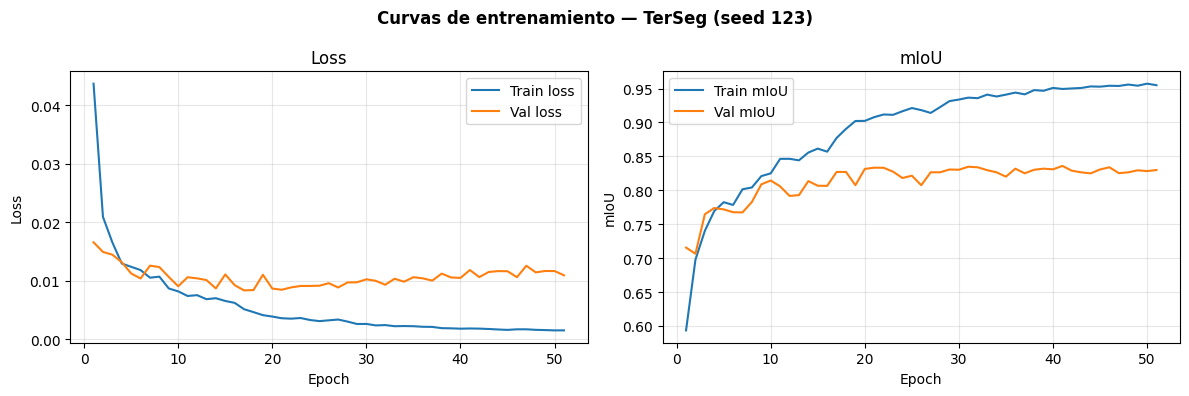

In [25]:
plot_best_seed_curves(summary)

In [26]:
# ── Bug 9 fix: limpiar fila anterior del mismo modelo ──
if BENCHMARK_CSV.exists():
    df_csv = pd.read_csv(BENCHMARK_CSV)
    df_csv = df_csv[df_csv["model"] != MODEL_NAME]
    df_csv.to_csv(BENCHMARK_CSV, index=False)

params_M = count_parameters(build_model())
append_benchmark_results(summary, params_M=params_M)
print('✅ Resultados guardados en results/benchmark_results.csv')

Resultados guardados en C:\Users\Hp\Documents\GitHub\ai4mars_DL-v3\results\benchmark_results.csv
✅ Resultados guardados en results/benchmark_results.csv


## 7. Visualización Cualitativa

⚠️ **Bug 8 fix**: summary NO tiene 'best_seed' ni 'checkpoints'. Calcular manualmente.

Mejor seed: 123 | mIoU gold: 0.8711


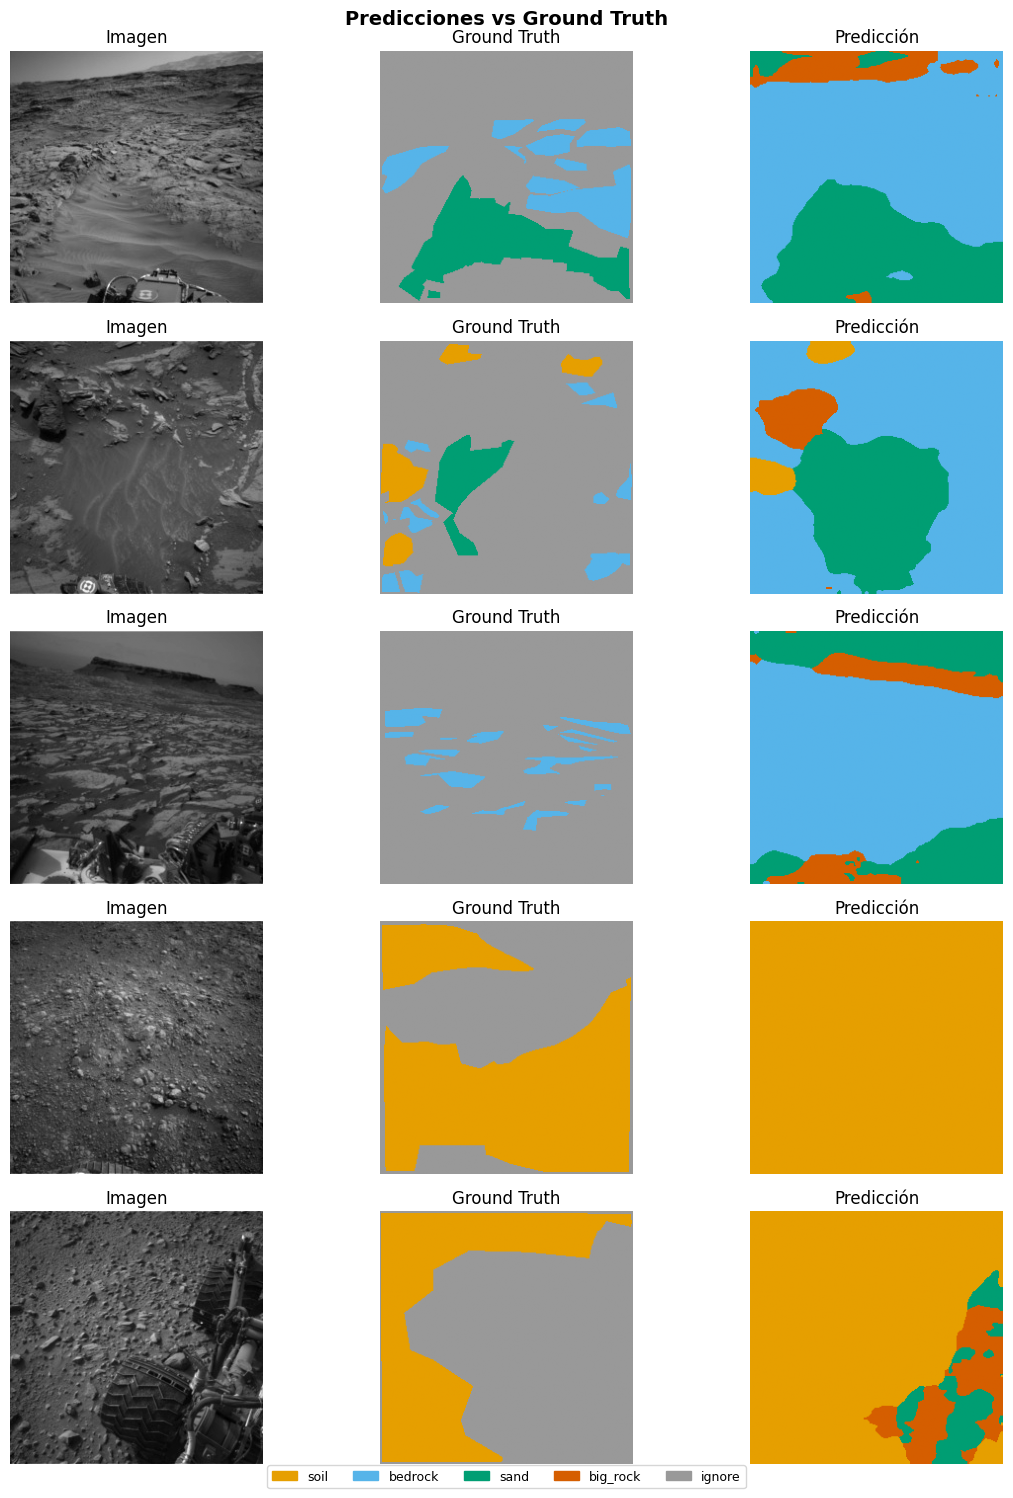

In [27]:
# ── Bug 8 fix: derivar best_seed manualmente ──
best_seed = max(summary["per_seed"], key=lambda r: r["mIoU"])["seed"]
best_miou = max(summary['per_seed'], key=lambda r: r['mIoU'])['mIoU']
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_seed{best_seed}_best.pth"

print(f"Mejor seed: {best_seed} | mIoU gold: {best_miou:.4f}")

best_model = build_model().to(DEVICE)
ckpt = torch.load(ckpt_path, map_location=DEVICE)
best_model.load_state_dict(ckpt["model_state"])
best_model.eval()

visualize_predictions(best_model, df_gold, DEVICE, mean=mean, std=std, n=5)

## 8. Resumen Final

| Campo | Valor |
|-------|-------|
| Modelo | TerSeg |
| Paper | Fan et al., Expert Systems with Applications 270 (2025) |
| Branch CNN | ResNet-34 pretrained |
| Branch Transformer | Swin-Tiny (timm) |
| Fusión | FL (stages 1-2) + FG (stages 3-4) |
| Decoder | FLGA multi-escala |
| Loss | FocalLoss (α=0.25, γ=2.0) |
| Optimizer | Adam (lr=1e-4) |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) |
| Swin input | Interpolado a 224×224 internamente |
| Referencia histórica (2.1k imgs) | mIoU = 0.7498 ± 0.0089 |

---
*Resultados del gold set exportados a `results/benchmark_results.csv`.*